In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df = pd.read_csv('Dataset_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [60]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [61]:
df.drop(['customerID'],axis=1,inplace=True)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [63]:
df['TotalCharges']= pd.to_numeric(df['TotalCharges'],errors='coerce')

In [64]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [65]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [66]:
k = df['StreamingMovies'].value_counts()
print(k)

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64


In [67]:
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


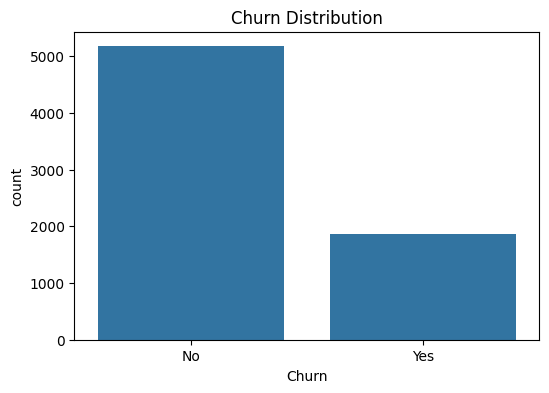

In [68]:
# Check churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn')
plt.title("Churn Distribution")
plt.show()

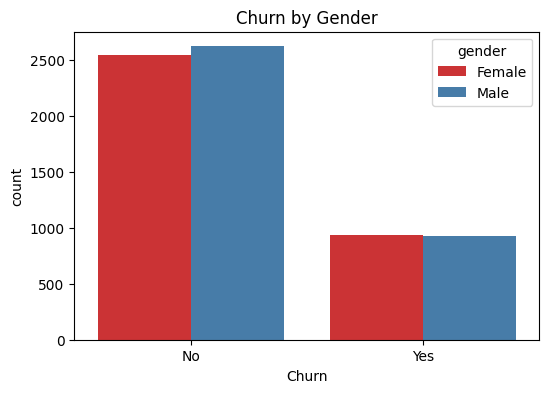

In [69]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='gender', palette='Set1')
plt.title("Churn by Gender")
plt.show()

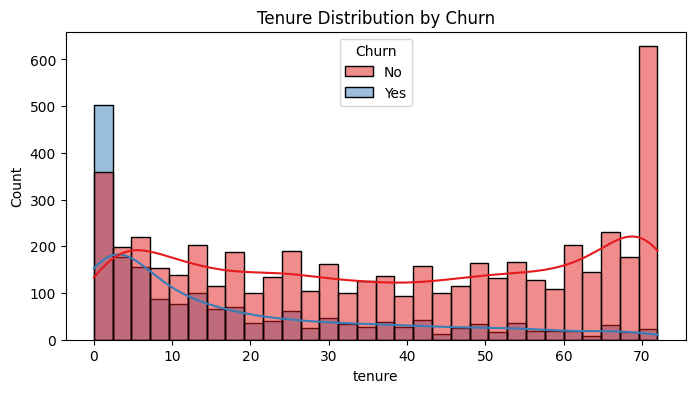

In [70]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, palette='Set1')
plt.title("Tenure Distribution by Churn")
plt.show()

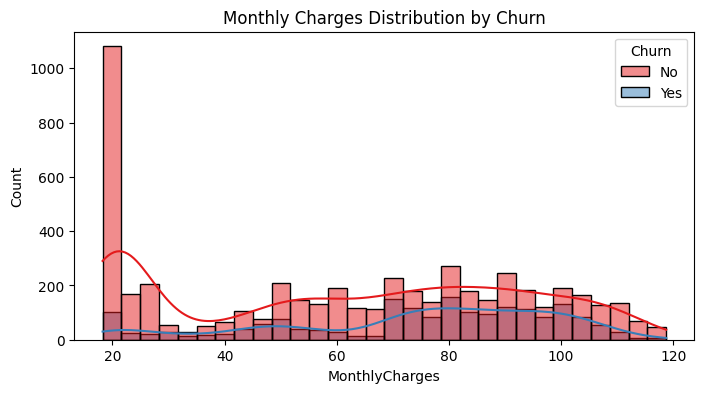

In [71]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True, palette='Set1')
plt.title("Monthly Charges Distribution by Churn")
plt.show()

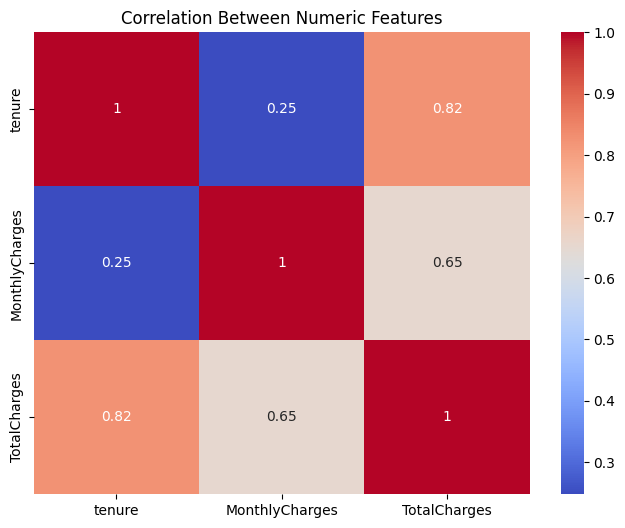

In [72]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Numeric Features")
plt.show()

In [73]:
df = pd.get_dummies(df,drop_first=True)

In [74]:
x = df.iloc[:,:-1]
y = df['Churn_Yes']

In [75]:
(y.value_counts()/len(y))*100

Churn_Yes
False    73.463013
True     26.536987
Name: count, dtype: float64

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [77]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [78]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

# Logistic Regression



In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
model = LogisticRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
acc = classification_report(y_test,y_pred)
print(acc)

              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1036
        True       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



bagging

In [80]:
from sklearn.ensemble import BaggingClassifier
bag = BaggingClassifier(estimator=LogisticRegression(),n_estimators=100,random_state=42,max_samples=0.5,bootstrap=True)
bag.fit(x_train,y_train)
y_pred = bag.predict(x_test)
acc11 = accuracy_score(y_test,y_pred)
print(acc11)

0.8218594748048261


boosting ada

In [81]:
from sklearn.ensemble import AdaBoostClassifier
boost = AdaBoostClassifier(estimator=LogisticRegression(),n_estimators=100,random_state=42)
boost.fit(x_train,y_train)
y_pred = boost.predict(x_test)
acc12 = accuracy_score(y_test,y_pred)
print(acc12)

0.7899219304471257


# KNN

In [82]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
model2 = KNeighborsClassifier()
model2.fit(x_train,y_train)
y_pred = model2.predict(x_test)
acc2 = accuracy_score(y_test,y_pred)
print(acc2)

0.7714691270404542


bagging

In [83]:
from sklearn.ensemble import BaggingClassifier
bag = BaggingClassifier(estimator=KNeighborsClassifier(),n_estimators=100,random_state=42,max_samples=0.5,bootstrap=True)
bag.fit(x_train,y_train)
y_pred = bag.predict(x_test)
acc21 = accuracy_score(y_test,y_pred)
print(acc21)

0.7977288857345636


# Decision Tree

In [84]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
model3 = DecisionTreeClassifier()
model3.fit(x_train,y_train)
y_pred = model3.predict(x_test)
acc3 = accuracy_score(y_test,y_pred)
print(acc3)

0.7182398864442867


bagging

In [85]:
from sklearn.ensemble import BaggingClassifier
bag = BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=100,random_state=42,max_samples=0.5,bootstrap=True)
bag.fit(x_train,y_train)
y_pred = bag.predict(x_test)
acc31 = accuracy_score(y_test,y_pred)
print(acc31)

0.7934705464868701


# Random Forest

In [86]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
model4 = RandomForestClassifier()
model4.fit(x_train,y_train)
y_pred = model4.predict(x_test)
acc4 = accuracy_score(y_test,y_pred)
print(acc4)

0.7920511000709723


bagging

In [88]:
from sklearn.ensemble import BaggingClassifier
bag = BaggingClassifier(estimator=RandomForestClassifier(),n_estimators=100,random_state=42,max_samples=0.5,bootstrap=True)
bag.fit(x_train,y_train)
y_pred = bag.predict(x_test)
acc41 = accuracy_score(y_test,y_pred)
print(acc41)


0.8105039034776437


# Boosting

In [89]:
from xgboost import XGBClassifier
boost = XGBClassifier(n_estimators=100,max_depth=4,learning_rate=0.1,random_state=42)
boost.fit(x_train,y_train)
y_pred = boost.predict(x_test)
acc42 = accuracy_score(y_test,y_pred)
print(acc42)

0.8126330731014905
